In [1]:
# We used the classification algorithm from initial project 
# we classify is a HTSC or isn't based on if its Tc is bigger than T_sup
# Imported and organised the data from the document : verify the percentage of HTSC ( 1 vs 0 ),  we will use balanced data all along - checked if not a number or for missing values -> none 
# Split the data into a training set and validation and test sets (75-15-10 percent) that have the smae ratio of HTSC  
#reduce variables : correlation matrice above 90percent correlation ; Mix of weight assignment using tree based model, permutation method, SHAP values method -> we take the top 20 of each ;then use Mix of The Recursive Feature Elimination method, Forward selection algorithm, and again weight assignment using tree based model, permutation method, SHAP we take the to ten of each. 
# Learning : We work we refined tabular dataset, we then wish to use XGBoost gradient-boosted trees. First we do a Baseline check with default parameters ( learning_rate = 0.3 - max_depth = 6 ) and then a Hyperparameter Optimization. 


In [2]:
!pip install shap

In [3]:
import pandas as pd
import numpy as np

print("=== Phase 2: Prepping Data for Regression ===\n")

# 1. Load the features (X) using pandas
print("Loading features...")
train_df = pd.read_csv('SuperCon_features.csv')

# 2. Load the critical temperatures (y) using numpy
print("Loading critical temperatures...")
y = np.load('SuperCon_critical_temperatures.npy')

# 3. Optional: Add the target variable directly into your pandas DataFrame 
# This is helpful if you want to look at everything together!
train_df['critical_temp'] = y

print(f"Features shape: {train_df.shape}")
print(f"Target shape: {y.shape}")

=== Phase 2: Prepping Data for Regression ===

Loading features...
Loading critical temperatures...
Features shape: (13661, 148)
Target shape: (13661,)


In [4]:
# 4. Define your NEW Target (y) and Features (X)
# For Regression, the answer key is the exact True Energy
y_train_reg = train_df['critical_temp']

# Your input sensors (X) are everything else EXCEPT the answer key
X_train_reg = train_df.drop(columns=['critical_temp'])

print("\n✅ Dataset is officially prepped for Regression!")
print(f"X (Sensors) shape: {X_train_reg.shape}")
print(f"y (Target Energy) shape: {y_train_reg.shape}")

# Display a quick peek at the new Target variable to see what you are predicting
print("\nA peek at the first 5 Temperature values you need to predict (in MeV):")
display(y_train_reg.head())


✅ Dataset is officially prepped for Regression!
X (Sensors) shape: (13661, 147)
y (Target Energy) shape: (13661,)

A peek at the first 5 Temperature values you need to predict (in MeV):


0    0
1    0
2    0
3    0
4    0
Name: critical_temp, dtype: int64

In [5]:
print("=== Variable Roster Check ===\n")

# 1. Extract the column names into a standard Python list
variable_names = train_df.columns.tolist()

# 2. Print the total count just to be safe
print(f"Total variables loaded: {len(variable_names)}\n")

# 3. Print them out in a clean, numbered list
print("📋 List of Features (Sensors):")
for i, var in enumerate(variable_names, start=1):
    print(f" {i}. {var}")

=== Variable Roster Check ===

Total variables loaded: 148

📋 List of Features (Sensors):
 1. MagpieData minimum Number
 2. MagpieData maximum Number
 3. MagpieData range Number
 4. MagpieData mean Number
 5. MagpieData avg_dev Number
 6. MagpieData mode Number
 7. MagpieData minimum MendeleevNumber
 8. MagpieData maximum MendeleevNumber
 9. MagpieData range MendeleevNumber
 10. MagpieData mean MendeleevNumber
 11. MagpieData avg_dev MendeleevNumber
 12. MagpieData mode MendeleevNumber
 13. MagpieData minimum AtomicWeight
 14. MagpieData maximum AtomicWeight
 15. MagpieData range AtomicWeight
 16. MagpieData mean AtomicWeight
 17. MagpieData avg_dev AtomicWeight
 18. MagpieData mode AtomicWeight
 19. MagpieData minimum MeltingT
 20. MagpieData maximum MeltingT
 21. MagpieData range MeltingT
 22. MagpieData mean MeltingT
 23. MagpieData avg_dev MeltingT
 24. MagpieData mode MeltingT
 25. MagpieData minimum Column
 26. MagpieData maximum Column
 27. MagpieData range Column
 28. MagpieDat

In [6]:
print("\n=== Phase 3: Prepping Data for Classification ===")

# 1. Define the temperature threshold
T_sup = 5.1

# 2. Create the new binary variable 'is_high_temp'
# .astype(int) converts the True/False boolean result into 1/0
train_df['is_high_temp'] = (train_df['critical_temp'] > T_sup).astype(int)

# 3. Suppress (drop) the original 'critical_temp' variable 
# to prevent target leakage
train_df = train_df.drop(columns=['critical_temp'])

# 4. Redefine your NEW Target (y) and Features (X) for Classification
y_train_class = train_df['is_high_temp']
X_train_class = train_df.drop(columns=['is_high_temp'])

print(f"✅ Dataset is officially prepped for Classification (Threshold: {T_sup} K)!")
print(f"X (Sensors) shape: {X_train_class.shape}")
print(f"y (Binary Target) shape: {y_train_class.shape}")

# Display a quick peek at the new Target variable 
print("\nA peek at the first 5 binary values you need to predict (1 = High Temp, 0 = Low Temp):")
display(y_train_class.head())

# Optional: Check the class balance (how many 1s vs 0s)
print("\nClass distribution:")
print(y_train_class.value_counts())


=== Phase 3: Prepping Data for Classification ===
✅ Dataset is officially prepped for Classification (Threshold: 5.1 K)!
X (Sensors) shape: (13661, 147)
y (Binary Target) shape: (13661,)

A peek at the first 5 binary values you need to predict (1 = High Temp, 0 = Low Temp):


0    0
1    0
2    0
3    0
4    0
Name: is_high_temp, dtype: int64


Class distribution:
is_high_temp
1    8564
0    5097
Name: count, dtype: int64


In [7]:
df = train_df

In [8]:

# We assume your dataset is already loaded into the variable 'df'

target_col = 'is_high_temp'

# First, let's make sure the column actually exists in the loaded data
if target_col in df.columns:
    
    # Calculate the percentage using the mean trick for binary data
    electron_percentage = df[target_col].mean() * 100
    
    # Get the exact raw counts of 0s and 1s
    value_counts = df[target_col].value_counts()
    true_electrons = value_counts.get(1, 0)
    non_electrons = value_counts.get(0, 0)
    
    print(f"Percentage of true electrons: {electron_percentage:.2f}%")
    print(f"Total True Electrons (1): {true_electrons:,}")
    print(f"Total Non-Electrons  (0): {non_electrons:,}")
    
else:
    print(f"❌ Error: The column '{target_col}' was not found in the DataFrame.")
    print("Here are the first few columns that ARE in the dataset:")
    print(list(df.columns)[:10])

Percentage of true electrons: 62.69%
Total True Electrons (1): 8,564
Total Non-Electrons  (0): 5,097


In [9]:

# We use pandas' built-in select_dtypes to exclude anything that is a number
non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()

if len(non_numeric_cols) == 0:
    print("✅ Great news! All variables in your dataset are numeric.")
    print("You don't need to do any text-to-number encoding.")
else:
    print(f"⚠️ Found {len(non_numeric_cols)} non-numeric variable(s):")
    
    # Let's list them out and see what data type they actually are
    for col in non_numeric_cols:
        col_type = df[col].dtype
        
        # Grab the first valid value as an example so you know what it looks like
        example_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else "All NaNs"
        
        print(f" - Column: '{col}' | Type: {col_type} | Example: {example_val}")

✅ Great news! All variables in your dataset are numeric.
You don't need to do any text-to-number encoding.


In [10]:

import numpy as np

# 1. Calculate total missing values (NaNs) per column
missing_counts = df.isna().sum()

# 2. Calculate the percentage of missing values
missing_percentages = (missing_counts / len(df)) * 100

# 3. Combine them into a nice readable table
missing_data = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentages
})

# 4. Filter to show ONLY columns with missing data and sort them
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

# 5. Display the results
if missing_data.empty:
    print("✅ Excellent! There are NO missing values in your dataset.")
else:
    print(f"⚠️ Found {len(missing_data)} column(s) with missing values:")
    display(missing_data)

# --- Bonus Check for Infinite Values ---
# Since all columns are numeric, we can safely check the whole dataframe
inf_counts = np.isinf(df).sum().sum()
if inf_counts == 0:
    print("✅ No infinite values found.")
else:
    print(f"\n⚠️ Warning: Found a total of {inf_counts} infinite values across the dataset!")

✅ Excellent! There are NO missing values in your dataset.
✅ No infinite values found.


In [6]:

from sklearn.model_selection import train_test_split

target_col = 'is_high_temp'

# Perform the 80/20 Stratified Split
train_df, val_df = train_test_split(
    df, 
    test_size=0.20,             # 20% goes to validation, 80% stays for training
    random_state=42,            # Sets a seed so you get the exact same split every time you run this
    stratify=df[target_col]     # CRITICAL: This guarantees the 21% class balance is maintained
)

# --- Verification ---
print("✅ Data successfully split!")
print(f"Original dataset shape:   {df.shape}")
print(f"Training set shape:       {train_df.shape} (80%)")
print(f"Validation set shape:     {val_df.shape} (20%)")

print("\n--- Verifying Class Balance ---")
train_balance = train_df[target_col].mean() * 100
val_balance = val_df[target_col].mean() * 100

print(f"Training set electrons:   {train_balance:.2f}%")
print(f"Validation set electrons: {val_balance:.2f}%")

✅ Data successfully split!
Original dataset shape:   (180000, 141)
Training set shape:       (144000, 141) (80%)
Validation set shape:     (36000, 141) (20%)

--- Verifying Class Balance ---
Training set electrons:   21.00%
Validation set electrons: 21.00%


In [11]:
from sklearn.model_selection import train_test_split

target_col = 'is_high_temp'

print("=== Creating a 3-Way Stratified Split (Train / Validation / Test) ===\n")

# --- STEP 1: Lock away the 10% TEST SET ---
# We split the main dataframe into a temporary training set (90%) and the final test set (10%)
temp_train_df, test_df = train_test_split(
    df, 
    test_size=0.10,             # 10% goes to the Vault
    random_state=42,            # Ensures the exact same split every time
    stratify=df[target_col]     # Maintains the 21% class balance
)

# --- STEP 2: Split the remaining 90% into TRAIN and VALIDATION ---
# We want 10% of the ORIGINAL data to be validation. 
# Since temp_train_df is 90% of the original, we take exactly 1/9th (11.11%) of it.
train_df, val_df = train_test_split(
    temp_train_df, 
    test_size=(0.15 / 0.90),    # Mathematically yields exactly 15% of total
    random_state=42,            
    stratify=temp_train_df[target_col]     
)

# --- Verification ---
print("✅ Data successfully split into 3 parts!")
print(f"Original dataset shape:   {df.shape}")
print(f"Training set shape:       {train_df.shape} (75%)")
print(f"Validation set shape:     {val_df.shape} (15%)")
print(f"Locked Test set shape:    {test_df.shape} (10%)")

print("\n--- Verifying Class Balance ---")
print(f"Training set electrons:   {train_df[target_col].mean() * 100:.2f}%")
print(f"Validation set electrons: {val_df[target_col].mean() * 100:.2f}%")
print(f"Locked Test set electrons:{test_df[target_col].mean() * 100:.2f}%")

=== Creating a 3-Way Stratified Split (Train / Validation / Test) ===

✅ Data successfully split into 3 parts!
Original dataset shape:   (13661, 148)
Training set shape:       (10245, 148) (75%)
Validation set shape:     (2049, 148) (15%)
Locked Test set shape:    (1367, 148) (10%)

--- Verifying Class Balance ---
Training set electrons:   62.69%
Validation set electrons: 62.66%
Locked Test set electrons:62.69%


In [12]:

# 1. Identify columns in the training set that have exactly 1 unique value
zero_variance_cols = [col for col in train_df.columns if train_df[col].nunique() == 1]

if len(zero_variance_cols) == 0:
    print("✅ No zero-variance columns found. Every feature has at least some variation.")
else:
    print(f"🧹 Found {len(zero_variance_cols)} zero-variance column(s). Dropping them now...\n")
    print("Columns excluded:")
    
    # Print the names of the dropped columns
    for col in zero_variance_cols:
        print(f" - {col}")
    
    # 2. Drop these columns from BOTH the training and validation sets
    train_df = train_df.drop(columns=zero_variance_cols)
    val_df = val_df.drop(columns=zero_variance_cols)
    
    print(f"\n✅ Drop complete!")
    print(f"New training set shape:   {train_df.shape}")
    print(f"New validation set shape: {val_df.shape}")

🧹 Found 1 zero-variance column(s). Dropping them now...

Columns excluded:
 - MagpieData minimum NfUnfilled

✅ Drop complete!
New training set shape:   (10245, 147)
New validation set shape: (2049, 147)


In [13]:


import numpy as np

# 1. Calculate the absolute correlation matrix using ONLY the training data
print("Calculating correlation matrix... (This might take a minute)")
corr_matrix = train_df.corr(method='pearson').abs()

# 2. Select the upper triangle of the correlation matrix
# This ensures that if A and B are highly correlated, we only drop B and keep A.
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Set the correlation threshold
threshold = 0.90

# 4. Find the features that exceed the threshold
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

# CRITICAL SAFETY CHECK: Never accidentally drop the target variable!
target_col = 'is_high_temp'
if target_col in to_drop:
    to_drop.remove(target_col)

# 5. Execute the drop
if len(to_drop) == 0:
    print(f"\n✅ No highly correlated variables found above the {threshold} threshold.")
else:
    print(f"\n✂️ Found {len(to_drop)} highly correlated column(s). Dropping them now...\n")
    
    # 6. Drop these columns from BOTH the training and validation sets
    train_df = train_df.drop(columns=to_drop)
    val_df = val_df.drop(columns=to_drop)
    
    print(f"✅ Drop complete!")
    print(f"New training set shape:   {train_df.shape}")
    print(f"New validation set shape: {val_df.shape}")

Calculating correlation matrix... (This might take a minute)

✂️ Found 49 highly correlated column(s). Dropping them now...

✅ Drop complete!
New training set shape:   (10245, 98)
New validation set shape: (2049, 98)


Training Random Forest on 97 variables to calculate weights... (This might take a minute)

✅ Top 30 Variables by Weight:


,Variable,Weight
0,MagpieData mode GSvolume_pa,0.065068
1,MagpieData avg_dev Column,0.060575
2,MagpieData mode Electronegativity,0.032771
3,MagpieData mode Number,0.026803
4,MagpieData avg_dev MeltingT,0.026432
5,MagpieData minimum MeltingT,0.026300
6,MagpieData minimum Column,0.025406
7,MagpieData range CovalentRadius,0.024709
8,MagpieData mean CovalentRadius,0.023946
9,MagpieData minimum MendeleevNumber,0.023729


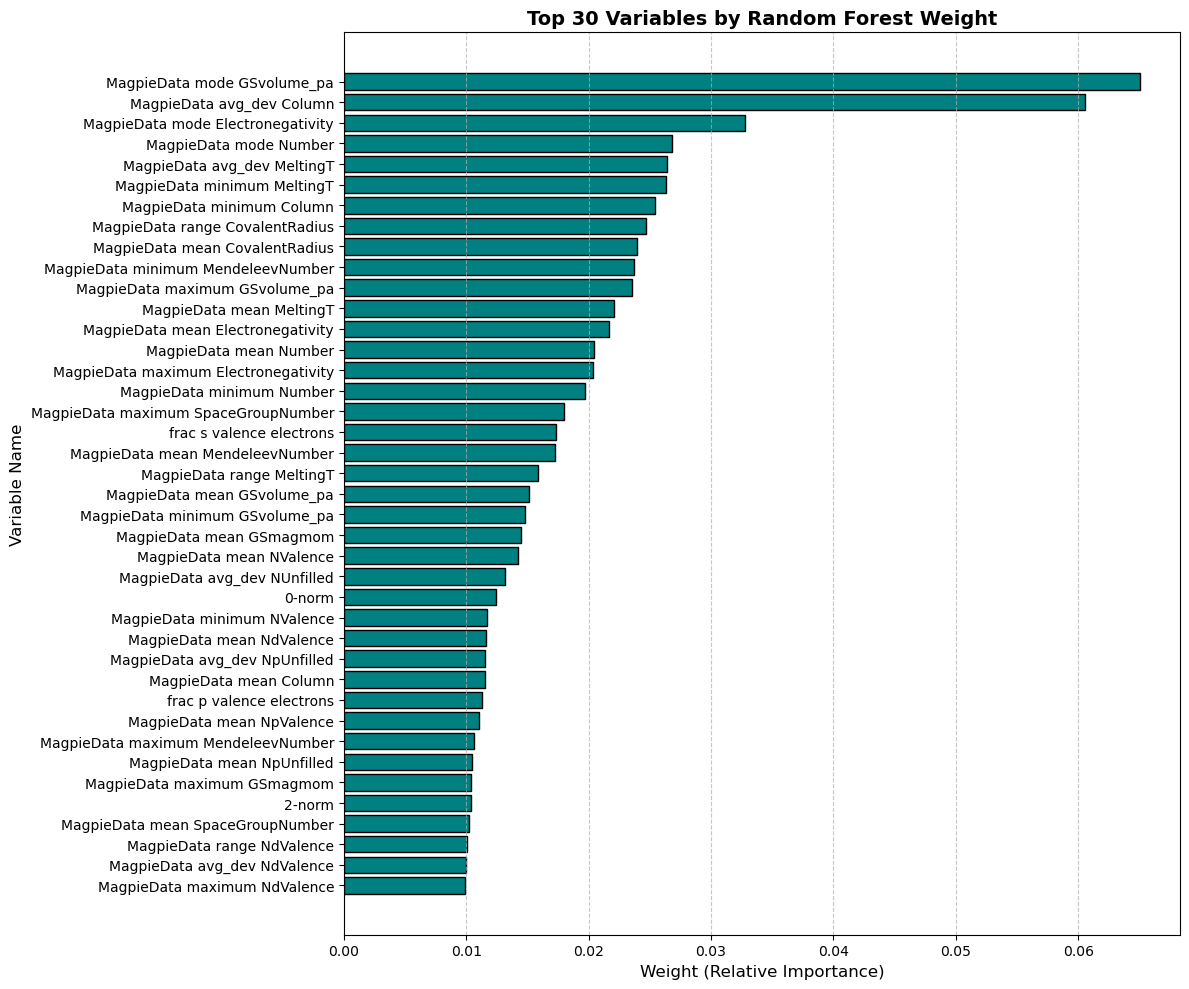

In [14]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define your features (X) and target (y) using ONLY the training data
target_col = 'is_high_temp'
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

print(f"Training Random Forest on {X_train.shape[1]} variables to calculate weights... (This might take a minute)\n")

# 2. Initialize and train the model
# - class_weight='balanced' perfectly handles your 21% electron imbalance
# - n_jobs=-1 tells your machine to use all available CPU cores to speed up training
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 3. Extract the weights (feature importances)
weights = rf_model.feature_importances_
features = X_train.columns

# 4. Create a DataFrame and sort it from most to least important
importance_df = pd.DataFrame({
    'Variable': features,
    'Weight': weights
}).sort_values(by='Weight', ascending=False).reset_index(drop=True)

# 5. Print the table (showing the top 30 to keep it manageable)
print("✅ Top 30 Variables by Weight:")
display(importance_df.head(40))

# 6. Plot the results
# We plot the top 30 so the graph remains highly readable
plt.figure(figsize=(12, 10))

# We reverse the order ([::-1]) just for the plot so the #1 feature appears at the very top
top_30 = importance_df.head(40)
plt.barh(top_30['Variable'][::-1], top_30['Weight'][::-1], color='teal', edgecolor='black')

plt.title('Top 30 Variables by Random Forest Weight', fontsize=14, fontweight='bold')
plt.xlabel('Weight (Relative Importance)', fontsize=12)
plt.ylabel('Variable Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

def compare_top_n_dfs(df1, df2, n, col_name='Variable'):
    """
    Takes two Pandas DataFrames, extracts the top 'n' variable names, 
    and checks for missing values between the two lists, completely ignoring weights.
    """
    
    # 1. Safety Check: Make sure the column actually exists in both tables
    if col_name not in df1.columns or col_name not in df2.columns:
        print(f"❌ Error: Could not find the column '{col_name}'.")
        print(f"Columns in Table 1: {list(df1.columns)}")
        print(f"Columns in Table 2: {list(df2.columns)}")
        return

    # 2. Extract strictly the top 'n' names from both DataFrames into simple lists
    # .head(n) grabs the top n rows, .tolist() converts them to plain text lists
    list1 = df1[col_name].head(n).tolist()
    list2 = df2[col_name].head(n).tolist()

    # 3. Compare Table 1 against Table 2
    print(f"=== Checking Top {n} of Table 1 against Table 2 ===")
    missing_from_df2 = False
    
    for i, val in enumerate(list1):
        if val not in list2:
            print(f" ⚠️ Rank {i + 1} in Table 1: '{val}' is missing from Table 2's top {n}.")
            missing_from_df2 = True
            
    if not missing_from_df2:
        print(f" ✅ All top {n} variables from Table 1 are present in Table 2!")

    # 4. Compare Table 2 against Table 1
    print(f"\n=== Checking Top {n} of Table 2 against Table 1 ===")
    missing_from_df1 = False
    
    for i, val in enumerate(list2):
        if val not in list1:
            print(f" ⚠️ Rank {i + 1} in Table 2: '{val}' is missing from Table 1's top {n}.")
            missing_from_df1 = True
            
    if not missing_from_df1:
        print(f" ✅ All top {n} variables from Table 2 are present in Table 1!")

In [16]:
top_40_100_10= top_30

In [17]:
#compare_top_n_dfs(top_40_100_15, top_40_100_10, 30)

In [18]:
# compare_top_features
import pandas as pd

def compare_top_features(top_30_0, top_30_1, col_name='Variable'):
    """
    Compares two ranked DataFrames and prints the rank differences and missing variables.
    """
    
    # 1. Create dictionaries mapping the Variable name to its Rank (1-based index)
    # enumerate(..., start=1) makes the top feature Rank 1 instead of Rank 0
    dict_0 = {var: rank for rank, var in enumerate(top_30_0[col_name], start=1)}
    dict_1 = {var: rank for rank, var in enumerate(top_30_1[col_name], start=1)}
    
    # 2. Extract the variables into sets for easy mathematical comparison
    set_0 = set(dict_0.keys())
    set_1 = set(dict_1.keys())
    
    # Find intersections and differences
    in_both = set_0.intersection(set_1)
    only_in_0 = set_0 - set_1
    only_in_1 = set_1 - set_0
    
    print("=== RANK DIFFERENCES FOR SHARED VARIABLES ===")
    differences_found = False
    
    for var in in_both:
        rank_0 = dict_0[var]
        rank_1 = dict_1[var]
        
        # Only print if the rank actually changed
        if rank_0 != rank_1:
            differences_found = True
            print(f"Variable '{var}' is ranked {rank_0} in top_30_0 whereas it's ranked {rank_1} in top_30_1.")
            
    if not differences_found:
        print("All shared variables have the exact same rank in both tables.")
        
    print("\n=== VARIABLES UNIQUE TO top_30_0 ===")
    if not only_in_0:
        print("None. All variables in top_30_0 are also in top_30_1.")
    else:
        for var in only_in_0:
            print(f"Variable '{var}' is in top_30_0 whereas it's not in top_30_1.")
            
    print("\n=== VARIABLES UNIQUE TO top_30_1 ===")
    if not only_in_1:
        print("None. All variables in top_30_1 are also in top_30_0.")
    else:
        for var in only_in_1:
            print(f"Variable '{var}' is in top_30_1 whereas it's not in top_30_0.")

# --- Example of how to run it ---
# compare_top_features(top_40_15, top_40_20)

Calculating Permutation Importance on 10000 rows... (This will take a minute or two)

✅ Top 30 Variables by Permutation Importance:


,Variable,Weight
0,MagpieData avg_dev Column,0.00424
1,MagpieData mean MeltingT,0.00394
2,MagpieData avg_dev MeltingT,0.00390
3,MagpieData mean CovalentRadius,0.00348
4,MagpieData mean GSvolume_pa,0.00330
5,MagpieData mode GSvolume_pa,0.00330
6,MagpieData avg_dev NUnfilled,0.00272
7,MagpieData mean SpaceGroupNumber,0.00262
8,MagpieData mode MendeleevNumber,0.00260
9,MagpieData mean MendeleevNumber,0.00248


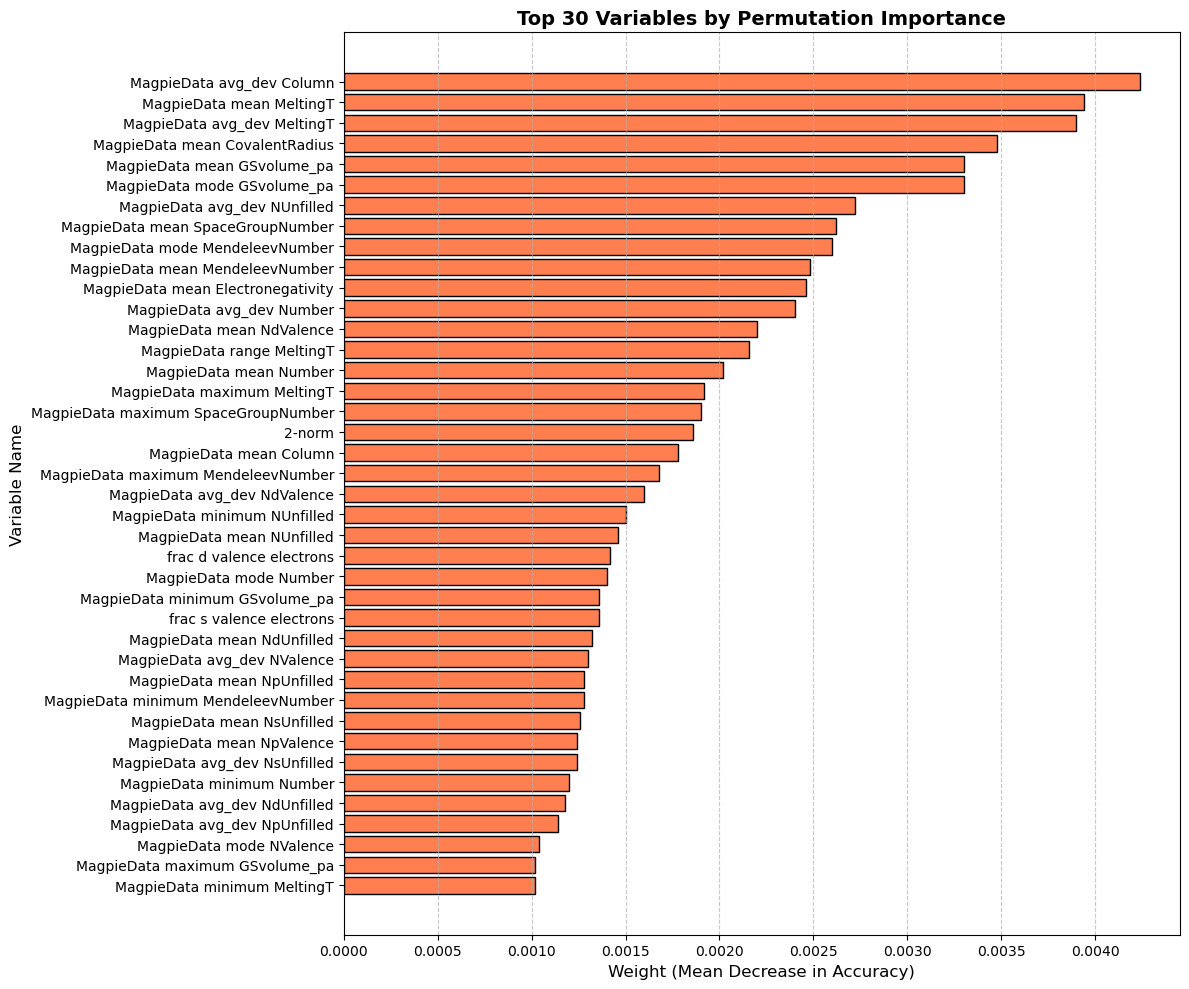

In [19]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# 1. Take a representative sample to speed up calculation
sample_size = 10000
X_sample = X_train.sample(n=sample_size, random_state=42)
y_sample = y_train.loc[X_sample.index]

print(f"Calculating Permutation Importance on {sample_size} rows... (This will take a minute or two)\n")

# 2. Run the Permutation Importance algorithm
# - rf_model: the Random Forest you already trained in the previous step
# - n_repeats=5: Shuffles each column 5 separate times and averages the result to prevent flukes
# - n_jobs=-1: Uses all available CPU cores
perm_results = permutation_importance(rf_model, X_sample, y_sample, n_repeats=5, random_state=42, n_jobs=-1)

# 3. Extract the mean weights (the average drop in accuracy when a column was shuffled)
perm_weights = perm_results.importances_mean
features = X_train.columns

# 4. Create a DataFrame and sort it from most to least important
perm_importance_df = pd.DataFrame({
    'Variable': features,
    'Weight': perm_weights
}).sort_values(by='Weight', ascending=False).reset_index(drop=True)

# 5. Print the table (Top 30)
print("✅ Top 30 Variables by Permutation Importance:")
display(perm_importance_df.head(40))

# 6. Plot the results
plt.figure(figsize=(12, 10))

# Take the top 30 and reverse the order for the bar chart so #1 is at the top
top_30_perm = perm_importance_df.head(40)
plt.barh(top_30_perm['Variable'][::-1], top_30_perm['Weight'][::-1], color='coral', edgecolor='black')

plt.title('Top 30 Variables by Permutation Importance', fontsize=14, fontweight='bold')
plt.xlabel('Weight (Mean Decrease in Accuracy)', fontsize=12)
plt.ylabel('Variable Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
#top_40_perm_15000 = top_30_perm

In [21]:
top_40_perm_10000 = top_30_perm

In [22]:
#compare_top_n_dfs(top_40_perm_15000, top_40_perm_10000, 30)

In [23]:
compare_top_n_dfs(top_40_100_10, top_40_perm_10000, 30)

=== Checking Top 30 of Table 1 against Table 2 ===
 ⚠️ Rank 3 in Table 1: 'MagpieData mode Electronegativity' is missing from Table 2's top 30.
 ⚠️ Rank 6 in Table 1: 'MagpieData minimum MeltingT' is missing from Table 2's top 30.
 ⚠️ Rank 7 in Table 1: 'MagpieData minimum Column' is missing from Table 2's top 30.
 ⚠️ Rank 8 in Table 1: 'MagpieData range CovalentRadius' is missing from Table 2's top 30.
 ⚠️ Rank 10 in Table 1: 'MagpieData minimum MendeleevNumber' is missing from Table 2's top 30.
 ⚠️ Rank 11 in Table 1: 'MagpieData maximum GSvolume_pa' is missing from Table 2's top 30.
 ⚠️ Rank 15 in Table 1: 'MagpieData maximum Electronegativity' is missing from Table 2's top 30.
 ⚠️ Rank 16 in Table 1: 'MagpieData minimum Number' is missing from Table 2's top 30.
 ⚠️ Rank 23 in Table 1: 'MagpieData mean GSmagmom' is missing from Table 2's top 30.
 ⚠️ Rank 24 in Table 1: 'MagpieData mean NValence' is missing from Table 2's top 30.
 ⚠️ Rank 26 in Table 1: '0-norm' is missing from Table

Calculating SHAP values on 2500 rows... (This will take a couple of minutes)

✅ Top 30 Variables by Global SHAP Importance:


,Variable,SHAP_Weight
0,MagpieData mode GSvolume_pa,0.034330
1,MagpieData avg_dev Column,0.032955
2,MagpieData maximum SpaceGroupNumber,0.018037
3,MagpieData mode Electronegativity,0.017330
4,MagpieData mode Number,0.016099
5,MagpieData minimum MeltingT,0.015364
6,MagpieData avg_dev MeltingT,0.014476
7,MagpieData range CovalentRadius,0.014271
8,MagpieData minimum MendeleevNumber,0.013699
9,MagpieData minimum Column,0.013349


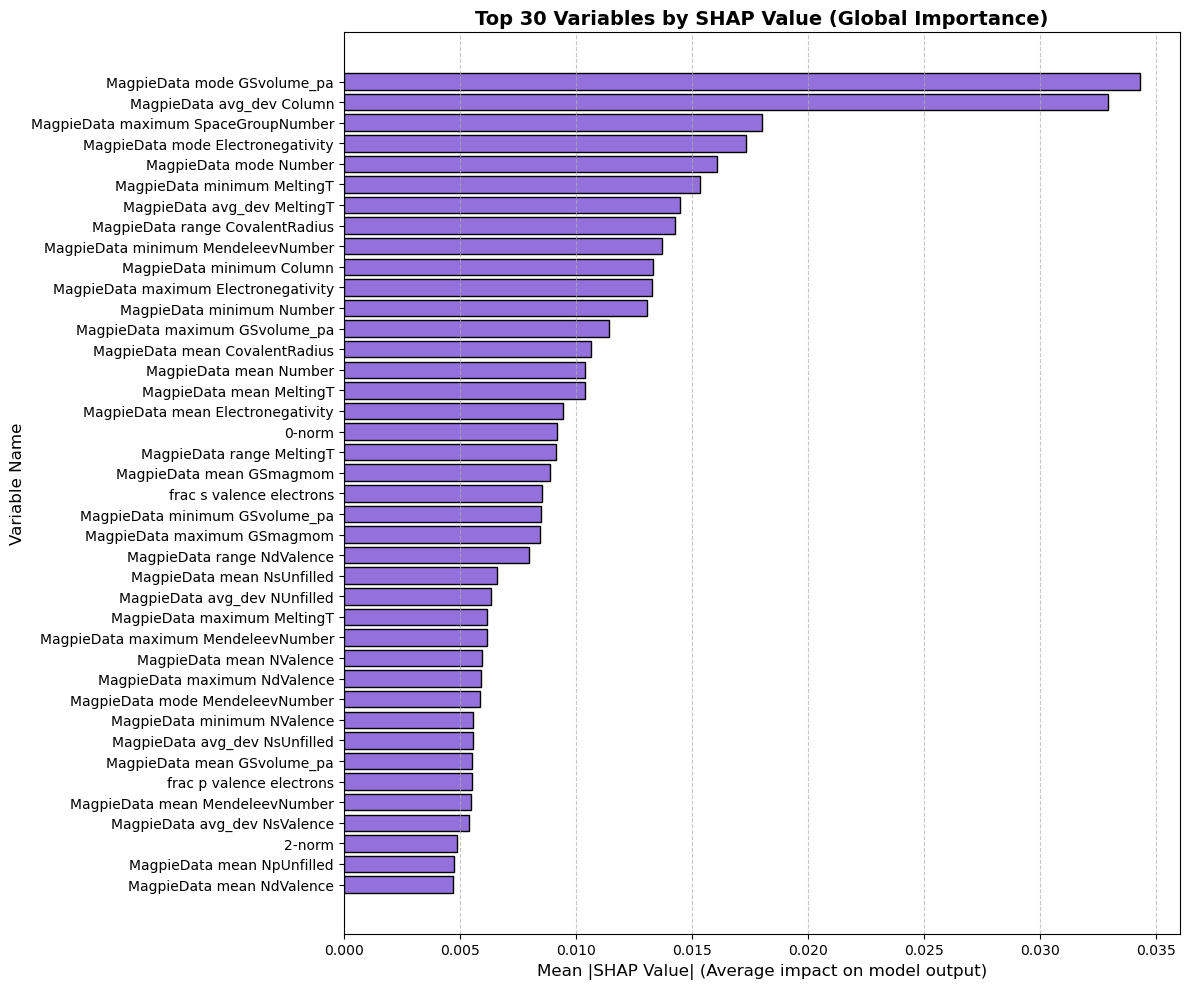


Generating SHAP Summary Plot (Beeswarm)...


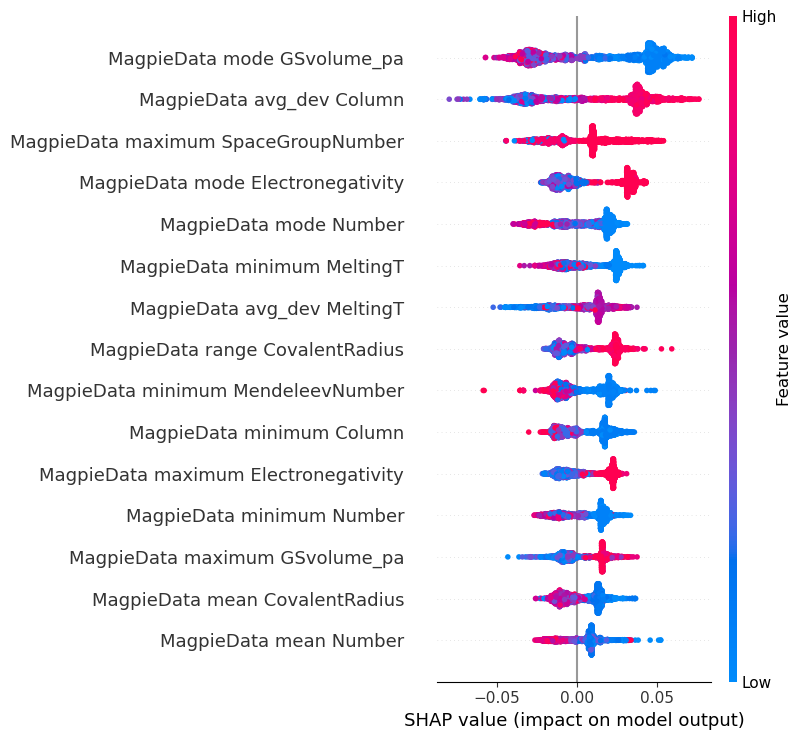

In [24]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Take a sample to make SHAP computationally feasible (e.g., 5,000 rows)
# We use the X_train that now contains your remaining 89 variables
sample_size = 2500
X_sample = X_train.sample(n=sample_size, random_state=42)

print(f"Calculating SHAP values on {sample_size} rows... (This will take a couple of minutes)\n")

# 2. Initialize the TreeExplainer with your trained Random Forest model
explainer = shap.TreeExplainer(rf_model)

# 3. Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# 4. Handle the output format (Bulletproof version)
if isinstance(shap_values, list):
    # Older SHAP versions return a list
    shap_values_target = shap_values[1]
elif len(shap_values.shape) == 3:
    # Newer SHAP versions return a 3D array: (samples, features, classes)
    # We want all samples, all features, but ONLY class 1 (the electron class)
    shap_values_target = shap_values[:, :, 1]
else:
    # Fallback just in case
    shap_values_target = shap_values

# 5. Calculate Global Feature Importance 
# This will now be perfectly flat (1-dimensional)
global_shap_importance = np.abs(shap_values_target).mean(axis=0)

# 6. Create the DataFrame
shap_importance_df = pd.DataFrame({
    'Variable': X_sample.columns,
    'SHAP_Weight': global_shap_importance
}).sort_values(by='SHAP_Weight', ascending=False).reset_index(drop=True)

# 7. Print the Top 30 table
print("✅ Top 30 Variables by Global SHAP Importance:")
display(shap_importance_df.head(30))

# 8. Plot the results in the consistent horizontal bar chart format
plt.figure(figsize=(12, 10))

# Take the top 30 and reverse for plotting so #1 is at the top
top_30_shap = shap_importance_df.head(40)
plt.barh(top_30_shap['Variable'][::-1], top_30_shap['SHAP_Weight'][::-1], color='mediumpurple', edgecolor='black')

plt.title('Top 30 Variables by SHAP Value (Global Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (Average impact on model output)', fontsize=12)
plt.ylabel('Variable Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- BONUS: The Standard SHAP Summary Plot ---
# This is the industry-standard visualization that shows the DIRECTION of the impact
print("\nGenerating SHAP Summary Plot (Beeswarm)...")
shap.summary_plot(shap_values_target, X_sample, max_display=15)

In [25]:
top_40_shap_2500 = top_30_shap

In [26]:
compare_top_n_dfs(top_40_perm_10000, top_40_shap_2500, 30)

=== Checking Top 30 of Table 1 against Table 2 ===
 ⚠️ Rank 5 in Table 1: 'MagpieData mean GSvolume_pa' is missing from Table 2's top 30.
 ⚠️ Rank 8 in Table 1: 'MagpieData mean SpaceGroupNumber' is missing from Table 2's top 30.
 ⚠️ Rank 9 in Table 1: 'MagpieData mode MendeleevNumber' is missing from Table 2's top 30.
 ⚠️ Rank 10 in Table 1: 'MagpieData mean MendeleevNumber' is missing from Table 2's top 30.
 ⚠️ Rank 12 in Table 1: 'MagpieData avg_dev Number' is missing from Table 2's top 30.
 ⚠️ Rank 13 in Table 1: 'MagpieData mean NdValence' is missing from Table 2's top 30.
 ⚠️ Rank 18 in Table 1: '2-norm' is missing from Table 2's top 30.
 ⚠️ Rank 19 in Table 1: 'MagpieData mean Column' is missing from Table 2's top 30.
 ⚠️ Rank 21 in Table 1: 'MagpieData avg_dev NdValence' is missing from Table 2's top 30.
 ⚠️ Rank 22 in Table 1: 'MagpieData minimum NUnfilled' is missing from Table 2's top 30.
 ⚠️ Rank 23 in Table 1: 'MagpieData mean NUnfilled' is missing from Table 2's top 30.
 

In [27]:
compare_top_n_dfs(top_40_100_10, top_40_shap_2500, 30)

=== Checking Top 30 of Table 1 against Table 2 ===
 ⚠️ Rank 19 in Table 1: 'MagpieData mean MendeleevNumber' is missing from Table 2's top 30.
 ⚠️ Rank 21 in Table 1: 'MagpieData mean GSvolume_pa' is missing from Table 2's top 30.
 ⚠️ Rank 27 in Table 1: 'MagpieData minimum NValence' is missing from Table 2's top 30.
 ⚠️ Rank 28 in Table 1: 'MagpieData mean NdValence' is missing from Table 2's top 30.
 ⚠️ Rank 29 in Table 1: 'MagpieData avg_dev NpUnfilled' is missing from Table 2's top 30.
 ⚠️ Rank 30 in Table 1: 'MagpieData mean Column' is missing from Table 2's top 30.

=== Checking Top 30 of Table 2 against Table 1 ===
 ⚠️ Rank 23 in Table 2: 'MagpieData maximum GSmagmom' is missing from Table 1's top 30.
 ⚠️ Rank 24 in Table 2: 'MagpieData range NdValence' is missing from Table 1's top 30.
 ⚠️ Rank 25 in Table 2: 'MagpieData mean NsUnfilled' is missing from Table 1's top 30.
 ⚠️ Rank 27 in Table 2: 'MagpieData maximum MeltingT' is missing from Table 1's top 30.
 ⚠️ Rank 28 in Table

In [28]:
# 1. Extract the variable names as sets for easy mathematical operations
set_tree = set(top_40_100_10.head(20)['Variable'])
set_shap = set(top_40_shap_2500.head(20)['Variable'])

# For permutation, we only want the top 5
set_perm_top5 = set(top_40_perm_10000.head(20)['Variable'])

# 2. Execute your logic: (Tree INTERSECT SHAP) UNION Perm_Top_5
final_features_set = (set_tree.union(set_shap)).union(set_perm_top5)

# Convert back to a list
final_features = list(final_features_set)

print(f"✅ Feature selection complete!")
print(f"Number of final variables selected: {len(final_features)}")

# Let's print them out to see what survived the gauntlet
print("\nFinal Feature List:")
for feat in final_features:
    print(f" - {feat}")

# 3. CRITICAL: Add the target column back so we don't accidentally drop our answers!
target_col = 'is_high_temp'
columns_to_keep = final_features + [target_col]

# 4. Filter both datasets down to ONLY these final columns
train_df = train_df[columns_to_keep]
val_df = val_df[columns_to_keep]

print(f"\n✅ Datasets successfully reduced!")
print(f"New training set shape:   {train_df.shape}")
print(f"New validation set shape: {val_df.shape}")

✅ Feature selection complete!
Number of final variables selected: 32

Final Feature List:
 - 0-norm
 - MagpieData minimum MendeleevNumber
 - MagpieData avg_dev Column
 - MagpieData range MeltingT
 - MagpieData maximum SpaceGroupNumber
 - frac s valence electrons
 - MagpieData avg_dev Number
 - MagpieData mode Electronegativity
 - MagpieData maximum Electronegativity
 - MagpieData minimum Column
 - MagpieData mean GSmagmom
 - MagpieData mode GSvolume_pa
 - MagpieData avg_dev NUnfilled
 - MagpieData mean SpaceGroupNumber
 - MagpieData mean Column
 - MagpieData mean Number
 - MagpieData minimum Number
 - MagpieData range CovalentRadius
 - MagpieData mean Electronegativity
 - MagpieData maximum MendeleevNumber
 - MagpieData maximum GSvolume_pa
 - MagpieData mean CovalentRadius
 - MagpieData mean MeltingT
 - MagpieData mode Number
 - MagpieData mode MendeleevNumber
 - MagpieData avg_dev MeltingT
 - MagpieData maximum MeltingT
 - MagpieData mean NdValence
 - MagpieData mean GSvolume_pa
 - Ma

In [29]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Isolate ONLY the features that survived your strict intersection/union logic
# final_features was created in the previous step, so we use it directly here!
X_train_final = X_train[final_features]

print(f"Running Recursive Feature Elimination (RFE) on our {len(final_features)} surviving variables...")
print("⏳ Note: This will run much faster now since we have fewer variables to test.\n")

# 2. Define a lighter baseline model for the judge
rfe_estimator = RandomForestClassifier(n_estimators=45, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)

# 3. Initialize the RFE algorithm
# We still set n_features_to_select=1 to force a complete ranking from 1 to the end
rfe = RFE(estimator=rfe_estimator, n_features_to_select=1, step=1)

# 4. Fit the RFE (The heavy lifting)
rfe.fit(X_train_final, y_train)

# 5. Extract the rankings
rfe_rankings = pd.DataFrame({
    'Variable': X_train_final.columns,
    'RFE_Rank': rfe.ranking_
})

# 6. Sort from Rank 1 (Ultimate Survivor) to the first eliminated
rfe_rankings_sorted = rfe_rankings.sort_values(by='RFE_Rank', ascending=True).reset_index(drop=True)

# 7. Print the final strictly ordered table
print("✅ Final RFE Complete! Here is the strict elimination ranking:")
display(rfe_rankings_sorted)

Running Recursive Feature Elimination (RFE) on our 32 surviving variables...
⏳ Note: This will run much faster now since we have fewer variables to test.

✅ Final RFE Complete! Here is the strict elimination ranking:


,Variable,RFE_Rank
0,MagpieData avg_dev Column,1
1,MagpieData mode GSvolume_pa,2
2,MagpieData mode Number,3
3,MagpieData avg_dev MeltingT,4
4,MagpieData mean MendeleevNumber,5
5,MagpieData mode Electronegativity,6
6,MagpieData mean MeltingT,7
7,MagpieData mean Number,8
8,MagpieData minimum MeltingT,9
9,MagpieData maximum SpaceGroupNumber,10


In [30]:
top_30_45_10 = rfe_rankings_sorted

Running Forward Selection on 32 variables using 5000 rows...
⏳ Note: This evaluates combinations step-by-step. It may take 1-2 minutes.

Rank 1 Added: 'MagpieData mode Number' | Model Accuracy: 0.8400
Rank 2 Added: 'MagpieData mean MendeleevNumber' | Model Accuracy: 0.8678
Rank 3 Added: 'MagpieData avg_dev Column' | Model Accuracy: 0.8828
Rank 4 Added: 'MagpieData maximum MendeleevNumber' | Model Accuracy: 0.8940
Rank 5 Added: 'MagpieData mean MeltingT' | Model Accuracy: 0.8982
Rank 6 Added: 'MagpieData avg_dev Number' | Model Accuracy: 0.8990
Rank 7 Added: 'MagpieData minimum Number' | Model Accuracy: 0.8984
Rank 8 Added: '0-norm' | Model Accuracy: 0.8994
Rank 9 Added: 'MagpieData mean CovalentRadius' | Model Accuracy: 0.9008
Rank 10 Added: 'MagpieData mean Electronegativity' | Model Accuracy: 0.9000
Rank 11 Added: 'MagpieData mean GSvolume_pa' | Model Accuracy: 0.9002
Rank 12 Added: 'MagpieData avg_dev MeltingT' | Model Accuracy: 0.9016
Rank 13 Added: 'MagpieData maximum Electronegat

,Forward_Rank,Variable,Accuracy
0,1,MagpieData mode Number,0.840001
1,2,MagpieData mean MendeleevNumber,0.867799
2,3,MagpieData avg_dev Column,0.882800
3,4,MagpieData maximum MendeleevNumber,0.894000
4,5,MagpieData mean MeltingT,0.898200
5,6,MagpieData avg_dev Number,0.899000
6,7,MagpieData minimum Number,0.898401
7,8,0-norm,0.899401
8,9,MagpieData mean CovalentRadius,0.900801
9,10,MagpieData mean Electronegativity,0.900001


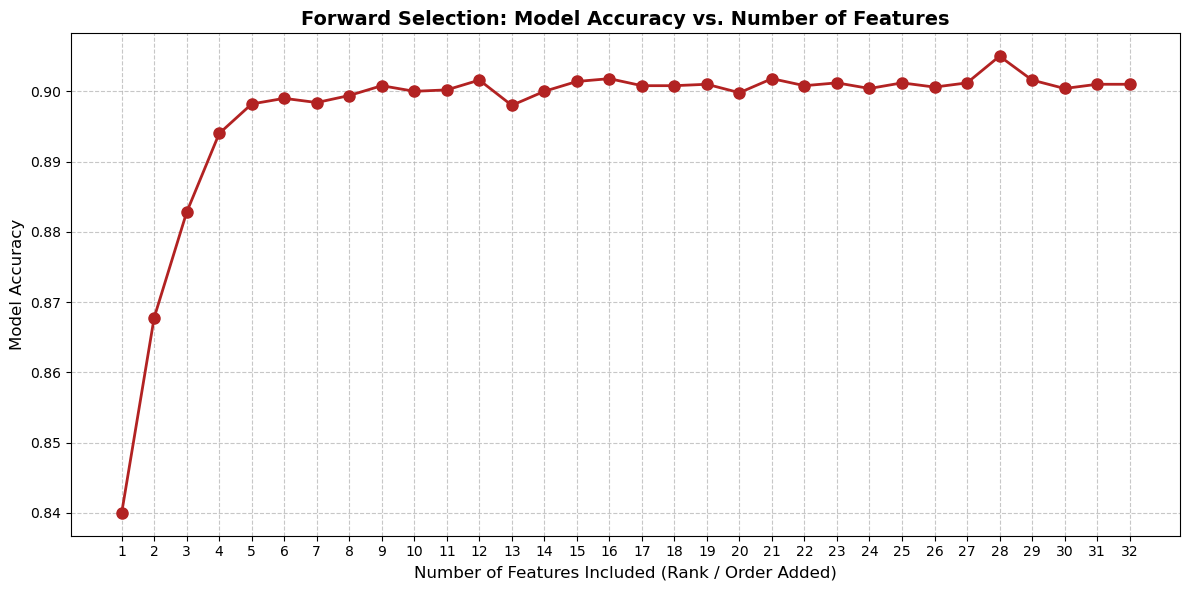

In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 1. Take a sample of 10,000 rows to make this computationally fast
sample_size = 5000
X_sample_fs = X_train_final.sample(n=sample_size, random_state=42)
y_sample_fs = y_train.loc[X_sample_fs.index]

# 2. Setup the tracking variables
remaining_features = list(X_sample_fs.columns)
selected_features = []
feature_ranks = []

print(f"Running Forward Selection on {len(remaining_features)} variables using {sample_size} rows...")
print("⏳ Note: This evaluates combinations step-by-step. It may take 1-2 minutes.\n")

# 3. Define the baseline model (The Judge)
fs_estimator = RandomForestClassifier(n_estimators=25, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)

# 4. The Custom Forward Selection Loop
for step in range(1, len(X_sample_fs.columns) + 1):
    best_score = 0
    best_feature = None
    
    # Test every feature that hasn't been selected yet
    for feature in remaining_features:
        # Create a temporary test set: The features we already picked + this new candidate
        current_test_set = selected_features + [feature]
        X_subset = X_sample_fs[current_test_set]
        
        # Evaluate this combination using 3-fold cross-validation
        scores = cross_val_score(fs_estimator, X_subset, y_sample_fs, cv=3, scoring='accuracy', n_jobs=-1)
        mean_score = scores.mean()
        
        # Keep track of the highest score in this round
        if mean_score > best_score:
            best_score = mean_score
            best_feature = feature
            
    # Officially add the winner of this round to our selected list
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    # Record the results
    feature_ranks.append({
        'Forward_Rank': step,
        'Variable': best_feature,
        'Accuracy': best_score
    })
    
    # Optional: Print progress so you know it hasn't frozen
    print(f"Rank {step} Added: '{best_feature}' | Model Accuracy: {best_score:.4f}")

# 5. Format the results into a clean table
forward_selection_df = pd.DataFrame(feature_ranks)

print("\n✅ Forward Selection Complete! Here is the strict addition ranking:")
display(forward_selection_df)

# 6. Plot the Forward Selection Learning Curve
# For Forward Selection, a line graph (Learning Curve) is the standard plot 
# because it shows exactly how much each added variable improved the model.
plt.figure(figsize=(12, 6))
plt.plot(forward_selection_df['Forward_Rank'], forward_selection_df['Accuracy'], marker='o', color='firebrick', linewidth=2, markersize=8)

plt.title('Forward Selection: Model Accuracy vs. Number of Features', fontsize=14, fontweight='bold')
plt.xlabel('Number of Features Included (Rank / Order Added)', fontsize=12)
plt.ylabel('Model Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, len(forward_selection_df) + 1))
plt.tight_layout()
plt.show()

In [32]:
top_20_forward_25000 = forward_selection_df

In [33]:
compare_top_n_dfs(top_30_45_10, top_20_forward_25000, 15)

=== Checking Top 15 of Table 1 against Table 2 ===
 ⚠️ Rank 2 in Table 1: 'MagpieData mode GSvolume_pa' is missing from Table 2's top 15.
 ⚠️ Rank 6 in Table 1: 'MagpieData mode Electronegativity' is missing from Table 2's top 15.
 ⚠️ Rank 8 in Table 1: 'MagpieData mean Number' is missing from Table 2's top 15.
 ⚠️ Rank 9 in Table 1: 'MagpieData minimum MeltingT' is missing from Table 2's top 15.
 ⚠️ Rank 10 in Table 1: 'MagpieData maximum SpaceGroupNumber' is missing from Table 2's top 15.
 ⚠️ Rank 12 in Table 1: 'MagpieData mean Column' is missing from Table 2's top 15.
 ⚠️ Rank 14 in Table 1: 'MagpieData mean GSmagmom' is missing from Table 2's top 15.

=== Checking Top 15 of Table 2 against Table 1 ===
 ⚠️ Rank 4 in Table 2: 'MagpieData maximum MendeleevNumber' is missing from Table 1's top 15.
 ⚠️ Rank 6 in Table 2: 'MagpieData avg_dev Number' is missing from Table 1's top 15.
 ⚠️ Rank 7 in Table 2: 'MagpieData minimum Number' is missing from Table 1's top 15.
 ⚠️ Rank 8 in Table 

In [34]:
# 1. Extract the 'Variable' column from both DataFrames and turn them into Python Sets
set_1 = set(top_30_45_10[:15]['Variable'])
set_2 = set(top_20_forward_25000[:15]['Variable'])

# 2. NOW you can safely use intersection!
top_15_final_set = set_1.intersection(set_2) # You can also use: set_1 & set_2

# 3. Convert the result back to a clean list to use later in your code
top_15_final = list(top_15_final_set)

print(f"✅ Intersection successful! Found {len(top_15_final)} overlapping variables:\n")
for var in top_15_final:
    print(f" - {var}")

✅ Intersection successful! Found 8 overlapping variables:

 - MagpieData maximum Electronegativity
 - MagpieData avg_dev Column
 - MagpieData mean MeltingT
 - MagpieData mean GSvolume_pa
 - MagpieData mode Number
 - MagpieData mean Electronegativity
 - MagpieData avg_dev MeltingT
 - MagpieData mean MendeleevNumber


Training a Random Forest on your 32 ensemble variables to find the Top 20... 

✅ Top 20 Variables Selected strictly from the Ensemble List:


,Variable,Weight
0,MagpieData mode GSvolume_pa,0.082649
1,MagpieData avg_dev Column,0.070729
2,MagpieData mode Number,0.061964
3,MagpieData mode Electronegativity,0.052298
4,MagpieData minimum MeltingT,0.041294
5,MagpieData maximum Electronegativity,0.040877
6,MagpieData range CovalentRadius,0.040773
7,MagpieData mean Number,0.040267
8,MagpieData mean CovalentRadius,0.035020
9,MagpieData avg_dev MeltingT,0.034400


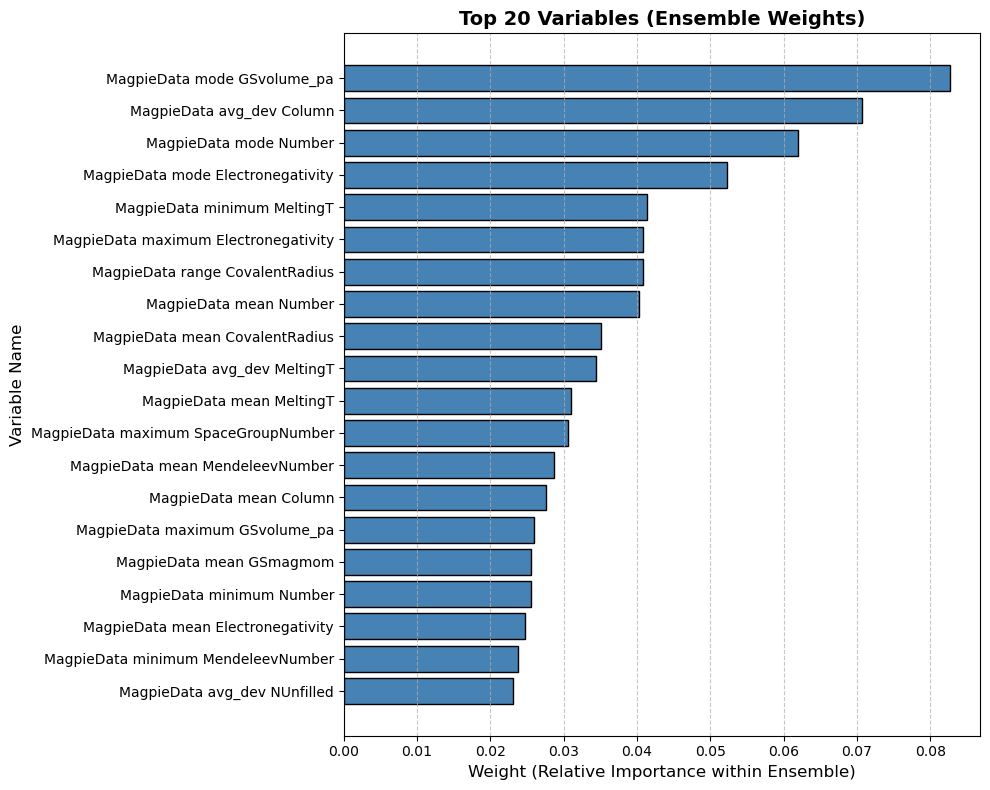


🔒 Note: Your datasets (train_df and val_df) were NOT modified during this step.


In [35]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 1. Isolate the features derived from your set logic: (Tree ∩ SHAP) ∪ Perm_Top_5
# We assume this list was saved as 'final_features' in the earlier step.
X_train_ensemble = X_train[final_features]

print(f"Training a Random Forest on your {len(final_features)} ensemble variables to find the Top 20... \n")

# 2. Initialize and train the model on JUST these consensus variables
rf_model_ensemble = RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model_ensemble.fit(X_train_ensemble, y_train)

# 3. Extract the new, highly focused weights
weights_ensemble = rf_model_ensemble.feature_importances_

# 4. Create a DataFrame and sort it from most to least important
importance_df_ensemble = pd.DataFrame({
    'Variable': X_train_ensemble.columns,
    'Weight': weights_ensemble
}).sort_values(by='Weight', ascending=False).reset_index(drop=True)

# 5. Slice the DataFrame to keep ONLY the top 20
top_20 = importance_df_ensemble.head(20)

# 6. Print the Top 20 table
print("✅ Top 20 Variables Selected strictly from the Ensemble List:")
display(top_20)

# 7. Plot the results in a horizontal bar chart
plt.figure(figsize=(10, 8))

# Reverse the order ([::-1]) just for the plot so Rank 1 is drawn at the very top
plt.barh(top_20['Variable'][::-1], top_20['Weight'][::-1], color='steelblue', edgecolor='black')

plt.title('Top 20 Variables (Ensemble Weights)', fontsize=14, fontweight='bold')
plt.xlabel('Weight (Relative Importance within Ensemble)', fontsize=12)
plt.ylabel('Variable Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n🔒 Note: Your datasets (train_df and val_df) were NOT modified during this step.")

In [36]:
# 1. Extract the variable names as sets from your DataFrames
set_top_20 = set(top_20['Variable'])
set_rfe_20 = set(rfe_rankings_sorted.head(20)['Variable'])
set_forward_11 = set(forward_selection_df.head(11)['Variable'])

# 2. Execute your logic: (top_20 ∩ rfe_20) - forward_11
# First, find the consensus between Top 20 and RFE
consensus_set = set_top_20.intersection(set_rfe_20)

# Then, remove the top 11 Forward Selection variables
final_custom_set = consensus_set - set_forward_11

# 3. Convert the final mathematical set back into a readable list
final_custom_features = list(final_custom_set)

# 4. Print the results
print(f"✅ Custom Feature Set Created!")
print(f"Number of variables remaining: {len(final_custom_features)}\n")

if len(final_custom_features) == 0:
    print("⚠️ The resulting list is empty. All consensus variables were removed by the Forward Selection subtraction.")
else:
    print("Your Final Custom Feature List:")
    for feat in final_custom_features:
        print(f" - {feat}")

✅ Custom Feature Set Created!
Number of variables remaining: 11

Your Final Custom Feature List:
 - MagpieData maximum Electronegativity
 - MagpieData avg_dev NUnfilled
 - MagpieData mode Electronegativity
 - MagpieData mean GSmagmom
 - MagpieData mode GSvolume_pa
 - MagpieData mean Column
 - MagpieData maximum SpaceGroupNumber
 - MagpieData mean Number
 - MagpieData minimum MeltingT
 - MagpieData avg_dev MeltingT
 - MagpieData maximum GSvolume_pa


Training a fresh Random Forest on your 32 ensemble variables...

Calculating Permutation Importance (shuffling columns) on 10000 rows... (This may take a minute)

✅ Top 20 Variables Selected by Permutation Importance (from Ensemble List):


,Variable,Perm_Weight
0,MagpieData mode GSvolume_pa,0.00838
1,MagpieData avg_dev Column,0.00810
2,MagpieData avg_dev MeltingT,0.00646
3,MagpieData maximum SpaceGroupNumber,0.00620
4,MagpieData mode Number,0.00614
5,MagpieData mean NdValence,0.00608
6,MagpieData mean MeltingT,0.00606
7,MagpieData avg_dev NUnfilled,0.00606
8,MagpieData mean Column,0.00598
9,MagpieData mean GSvolume_pa,0.00556


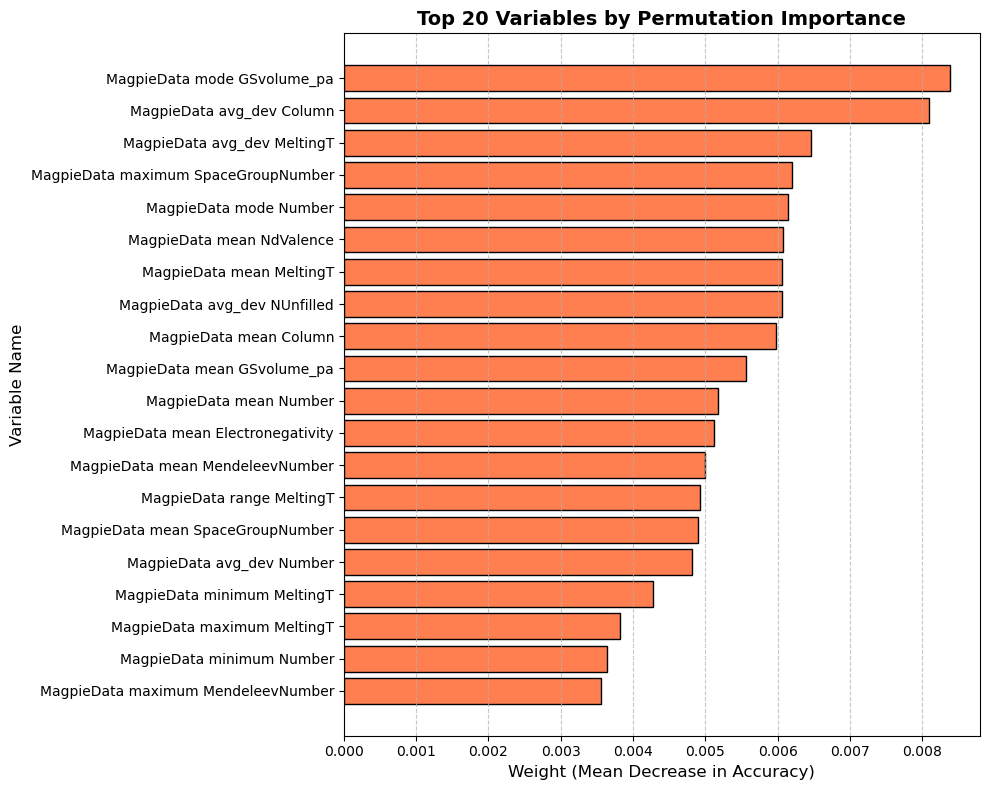


🔒 Note: Your datasets (train_df and val_df) were NOT modified during this step.


In [37]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 1. Isolate the features derived strictly from your set logic: (Tree ∩ SHAP) ∪ Perm_Top_5
# We assume this list is saved in the variable 'final_features'
X_train_ensemble = X_train[final_features]

print(f"Training a fresh Random Forest on your {len(final_features)} ensemble variables...\n")

# 2. Train the model on ALL training rows for these specific variables to ensure high accuracy
rf_model_ensemble = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model_ensemble.fit(X_train_ensemble, y_train)

# 3. Take a 10,000-row sample to run the permutation test (to save computation time)
sample_size = 10000
X_sample_perm = X_train_ensemble.sample(n=sample_size, random_state=42)
y_sample_perm = y_train.loc[X_sample_perm.index]

print(f"Calculating Permutation Importance (shuffling columns) on {sample_size} rows... (This may take a minute)\n")

# 4. Run the Permutation Importance algorithm
perm_results = permutation_importance(rf_model_ensemble, X_sample_perm, y_sample_perm, n_repeats=5, random_state=42, n_jobs=-1)

# 5. Extract the mean weights (the average drop in accuracy when shuffled)
perm_weights_ensemble = perm_results.importances_mean

# 6. Create a DataFrame and sort it from most to least important
perm_importance_df_ensemble = pd.DataFrame({
    'Variable': X_train_ensemble.columns,
    'Perm_Weight': perm_weights_ensemble
}).sort_values(by='Perm_Weight', ascending=False).reset_index(drop=True)

# 7. Slice the DataFrame to keep ONLY the top 20
top_20_perm_final = perm_importance_df_ensemble.head(20)

# 8. Print the Top 20 table
print("✅ Top 20 Variables Selected by Permutation Importance (from Ensemble List):")
display(top_20_perm_final)

# 9. Plot the results in a horizontal bar chart
plt.figure(figsize=(10, 8))

# Reverse the order ([::-1]) just for the plot so Rank 1 is drawn at the very top
plt.barh(top_20_perm_final['Variable'][::-1], top_20_perm_final['Perm_Weight'][::-1], color='coral', edgecolor='black')

plt.title('Top 20 Variables by Permutation Importance', fontsize=14, fontweight='bold')
plt.xlabel('Weight (Mean Decrease in Accuracy)', fontsize=12)
plt.ylabel('Variable Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 10. Safety confirmation
print("\n🔒 Note: Your datasets (train_df and val_df) were NOT modified during this step.")

In [38]:
# 1. Extract the variable names as sets from your DataFrames
set_top_20 = set(top_20_perm_final['Variable'])
set_rfe_20 = set(rfe_rankings_sorted.head(20)['Variable'])
set_forward_11 = set(forward_selection_df.head(11)['Variable'])

# 2. Execute your logic: (top_20 ∩ rfe_20) - forward_11
# First, find the consensus between Top 20 and RFE
consensus_set = set_top_20.intersection(set_rfe_20)

# Then, remove the top 11 Forward Selection variables
final_custom_set = consensus_set - set_forward_11

# 3. Convert the final mathematical set back into a readable list
final_custom_features = list(final_custom_set)

# 4. Print the results
print(f"✅ Custom Feature Set Created!")
print(f"Number of variables remaining: {len(final_custom_features)}\n")

if len(final_custom_features) == 0:
    print("⚠️ The resulting list is empty. All consensus variables were removed by the Forward Selection subtraction.")
else:
    print("Your Final Custom Feature List:")
    for feat in final_custom_features:
        print(f" - {feat}")

✅ Custom Feature Set Created!
Number of variables remaining: 9

Your Final Custom Feature List:
 - MagpieData avg_dev NUnfilled
 - MagpieData mode GSvolume_pa
 - MagpieData mean Column
 - MagpieData range MeltingT
 - MagpieData maximum SpaceGroupNumber
 - MagpieData mean Number
 - MagpieData mean NdValence
 - MagpieData minimum MeltingT
 - MagpieData avg_dev MeltingT


Training a fresh Random Forest on your 32 clean ensemble variables...

Calculating SHAP values on 2500 rows... (This will take a minute)

✅ Top 20 Variables Selected by SHAP (from Ensemble List):


,Variable,SHAP_Weight
0,MagpieData mode GSvolume_pa,0.039466
1,MagpieData mode Number,0.035785
2,MagpieData avg_dev Column,0.033243
3,MagpieData mode Electronegativity,0.033104
4,MagpieData maximum SpaceGroupNumber,0.027665
5,MagpieData range CovalentRadius,0.027589
6,MagpieData minimum MeltingT,0.024636
7,MagpieData maximum Electronegativity,0.020214
8,MagpieData mean Number,0.018416
9,MagpieData minimum Number,0.015897


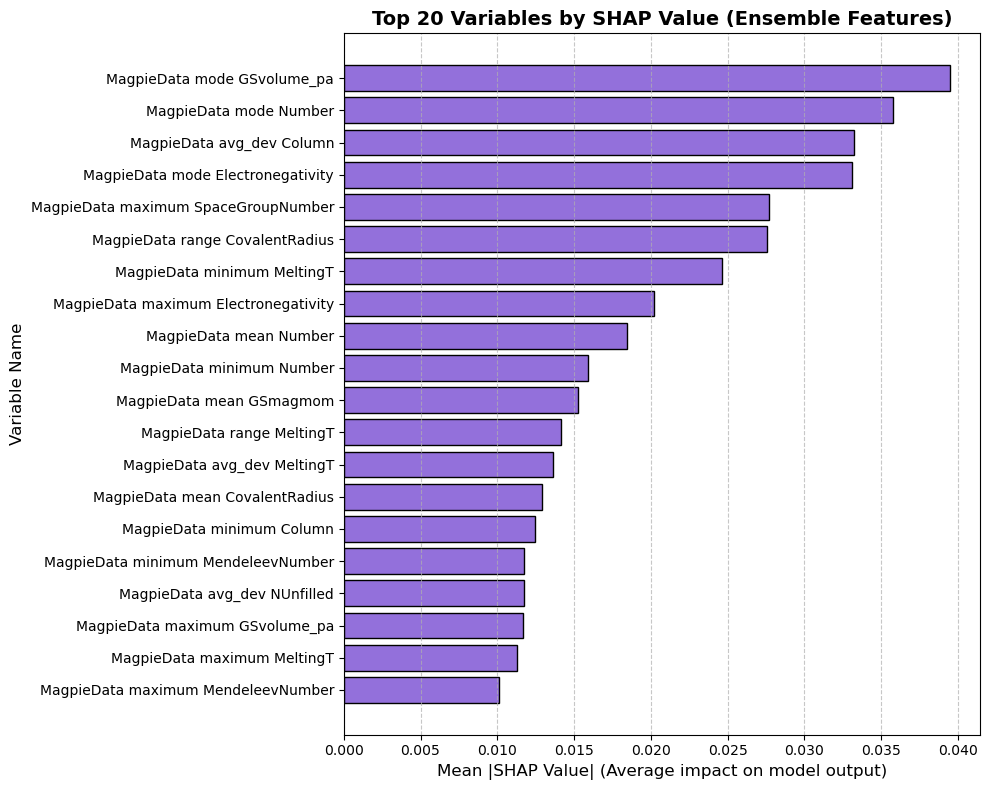


🔒 Note: Your datasets (train_df and val_df) were NOT modified during this step.


In [39]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# --- THE FIX: Clean the final_features list before using it ---
# This safely removes p_Truth_Energy or any other 'Truth' columns that got stuck in the list
safe_final_features = [feat for feat in final_features if 'Truth' not in feat and 'truth' not in feat]

# 1. Isolate the features derived strictly from your set logic
X_train_ensemble = X_train[safe_final_features]

print(f"Training a fresh Random Forest on your {len(safe_final_features)} clean ensemble variables...\n")

# 2. Train the baseline model on ALL training rows for these specific variables
rf_model_ensemble = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model_ensemble.fit(X_train_ensemble, y_train)

# 3. Take a 5,000-row sample to make SHAP computationally feasible
sample_size = 2500
X_sample_shap = X_train_ensemble.sample(n=sample_size, random_state=42)

print(f"Calculating SHAP values on {sample_size} rows... (This will take a minute)\n")

# 4. Initialize the TreeExplainer with your newly trained ensemble model
explainer = shap.TreeExplainer(rf_model_ensemble)

# 5. Calculate SHAP values
shap_values_ensemble = explainer.shap_values(X_sample_shap)

# 6. Handle the output format (Bulletproof version for all shap versions)
if isinstance(shap_values_ensemble, list):
    # Older SHAP versions
    shap_values_target = shap_values_ensemble[1]
elif len(shap_values_ensemble.shape) == 3:
    # Newer SHAP versions: (samples, features, classes)
    shap_values_target = shap_values_ensemble[:, :, 1]
else:
    # Fallback
    shap_values_target = shap_values_ensemble

# 7. Calculate Global Feature Importance (Mean absolute SHAP value)
global_shap_importance = np.abs(shap_values_target).mean(axis=0)

# 8. Create a DataFrame and sort it from most to least important
shap_importance_df_ensemble = pd.DataFrame({
    'Variable': X_train_ensemble.columns,
    'SHAP_Weight': global_shap_importance
}).sort_values(by='SHAP_Weight', ascending=False).reset_index(drop=True)

# 9. Slice the DataFrame to keep ONLY the top 20
top_20_shap_final = shap_importance_df_ensemble.head(20)

# 10. Print the Top 20 table
print("✅ Top 20 Variables Selected by SHAP (from Ensemble List):")
display(top_20_shap_final)

# 11. Plot the results in a horizontal bar chart
plt.figure(figsize=(10, 8))

# Reverse the order ([::-1]) just for the plot so Rank 1 is drawn at the very top
plt.barh(top_20_shap_final['Variable'][::-1], top_20_shap_final['SHAP_Weight'][::-1], color='mediumpurple', edgecolor='black')

plt.title('Top 20 Variables by SHAP Value (Ensemble Features)', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (Average impact on model output)', fontsize=12)
plt.ylabel('Variable Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 12. Safety confirmation
print("\n🔒 Note: Your datasets (train_df and val_df) were NOT modified during this step.")

In [40]:
top_20_shap_final = shap_importance_df_ensemble.head(40)

In [41]:
top_40_shap_2500 = top_20_shap_final

In [42]:
# 1. Extract the variable names as sets from your DataFrames
set_top_20 = set(top_20_shap_final['Variable'])
set_rfe_20 = set(rfe_rankings_sorted.head(20)['Variable'])
set_forward_11 = set(forward_selection_df.head(11)['Variable'])

# 2. Execute your logic: (top_20 ∩ rfe_20) - forward_11
# First, find the consensus between Top 20 and RFE
consensus_set = set_top_20.intersection(set_rfe_20)

# Then, remove the top 11 Forward Selection variables
final_custom_set = consensus_set - set_forward_11

# 3. Convert the final mathematical set back into a readable list
final_custom_features = list(final_custom_set)

# 4. Print the results
print(f"✅ Custom Feature Set Created!")
print(f"Number of variables remaining: {len(final_custom_features)}\n")

if len(final_custom_features) == 0:
    print("⚠️ The resulting list is empty. All consensus variables were removed by the Forward Selection subtraction.")
else:
    print("Your Final Custom Feature List:")
    for feat in final_custom_features:
        print(f" - {feat}")

✅ Custom Feature Set Created!
Number of variables remaining: 14

Your Final Custom Feature List:
 - MagpieData maximum Electronegativity
 - MagpieData mode Electronegativity
 - MagpieData avg_dev NUnfilled
 - MagpieData mean GSmagmom
 - MagpieData mode GSvolume_pa
 - MagpieData mean Column
 - MagpieData range MeltingT
 - MagpieData minimum MeltingT
 - MagpieData maximum SpaceGroupNumber
 - MagpieData mean Number
 - MagpieData mean NdValence
 - frac s valence electrons
 - MagpieData avg_dev MeltingT
 - MagpieData maximum GSvolume_pa


In [44]:
# 1. Force the base list to be a standard Python list
final_custom_features = list(top_15_final)

print("=== Processing Automated Variable Additions ===\n")

# 2. Extract the first 10 values AND force them into standard lists
shap_top_10 = list(top_20_shap_final[:10]['Variable'])
perm_top_10 = list(top_20_perm_final[:10]['Variable'])
other_top_10 = list(top_20[:10]['Variable'])

# 3. Combine the lists
# Because they are now standard lists, the '+' operator will safely append the items
candidates_to_add = shap_top_10 + perm_top_10 + other_top_10

# 4. Loop through your new candidates and safely add them
for var in candidates_to_add:
    if var in final_custom_features:
        print(f"⚠️ '{var}' is already in the feature list. Skipping duplicate.")
    else:
        final_custom_features.append(var)
        print(f"✅ Successfully added '{var}'.")

# 5. Print the final results
print(f"\n=== Final Feature List Generated ===")
print(f"Total number of variables: {len(final_custom_features)}\n")

=== Processing Automated Variable Additions ===

✅ Successfully added 'MagpieData mode GSvolume_pa'.
⚠️ 'MagpieData mode Number' is already in the feature list. Skipping duplicate.
⚠️ 'MagpieData avg_dev Column' is already in the feature list. Skipping duplicate.
✅ Successfully added 'MagpieData mode Electronegativity'.
✅ Successfully added 'MagpieData maximum SpaceGroupNumber'.
✅ Successfully added 'MagpieData range CovalentRadius'.
✅ Successfully added 'MagpieData minimum MeltingT'.
⚠️ 'MagpieData maximum Electronegativity' is already in the feature list. Skipping duplicate.
✅ Successfully added 'MagpieData mean Number'.
✅ Successfully added 'MagpieData minimum Number'.
⚠️ 'MagpieData mode GSvolume_pa' is already in the feature list. Skipping duplicate.
⚠️ 'MagpieData avg_dev Column' is already in the feature list. Skipping duplicate.
⚠️ 'MagpieData avg_dev MeltingT' is already in the feature list. Skipping duplicate.
⚠️ 'MagpieData maximum SpaceGroupNumber' is already in the feature

=== Generating Pairwise Scatter Plots ===

Taking a random sample of 500 rows for safe visualization...
Generating a 19x19 grid of plots...
(This might take a couple of minutes depending on your computer. Please wait ⏳)


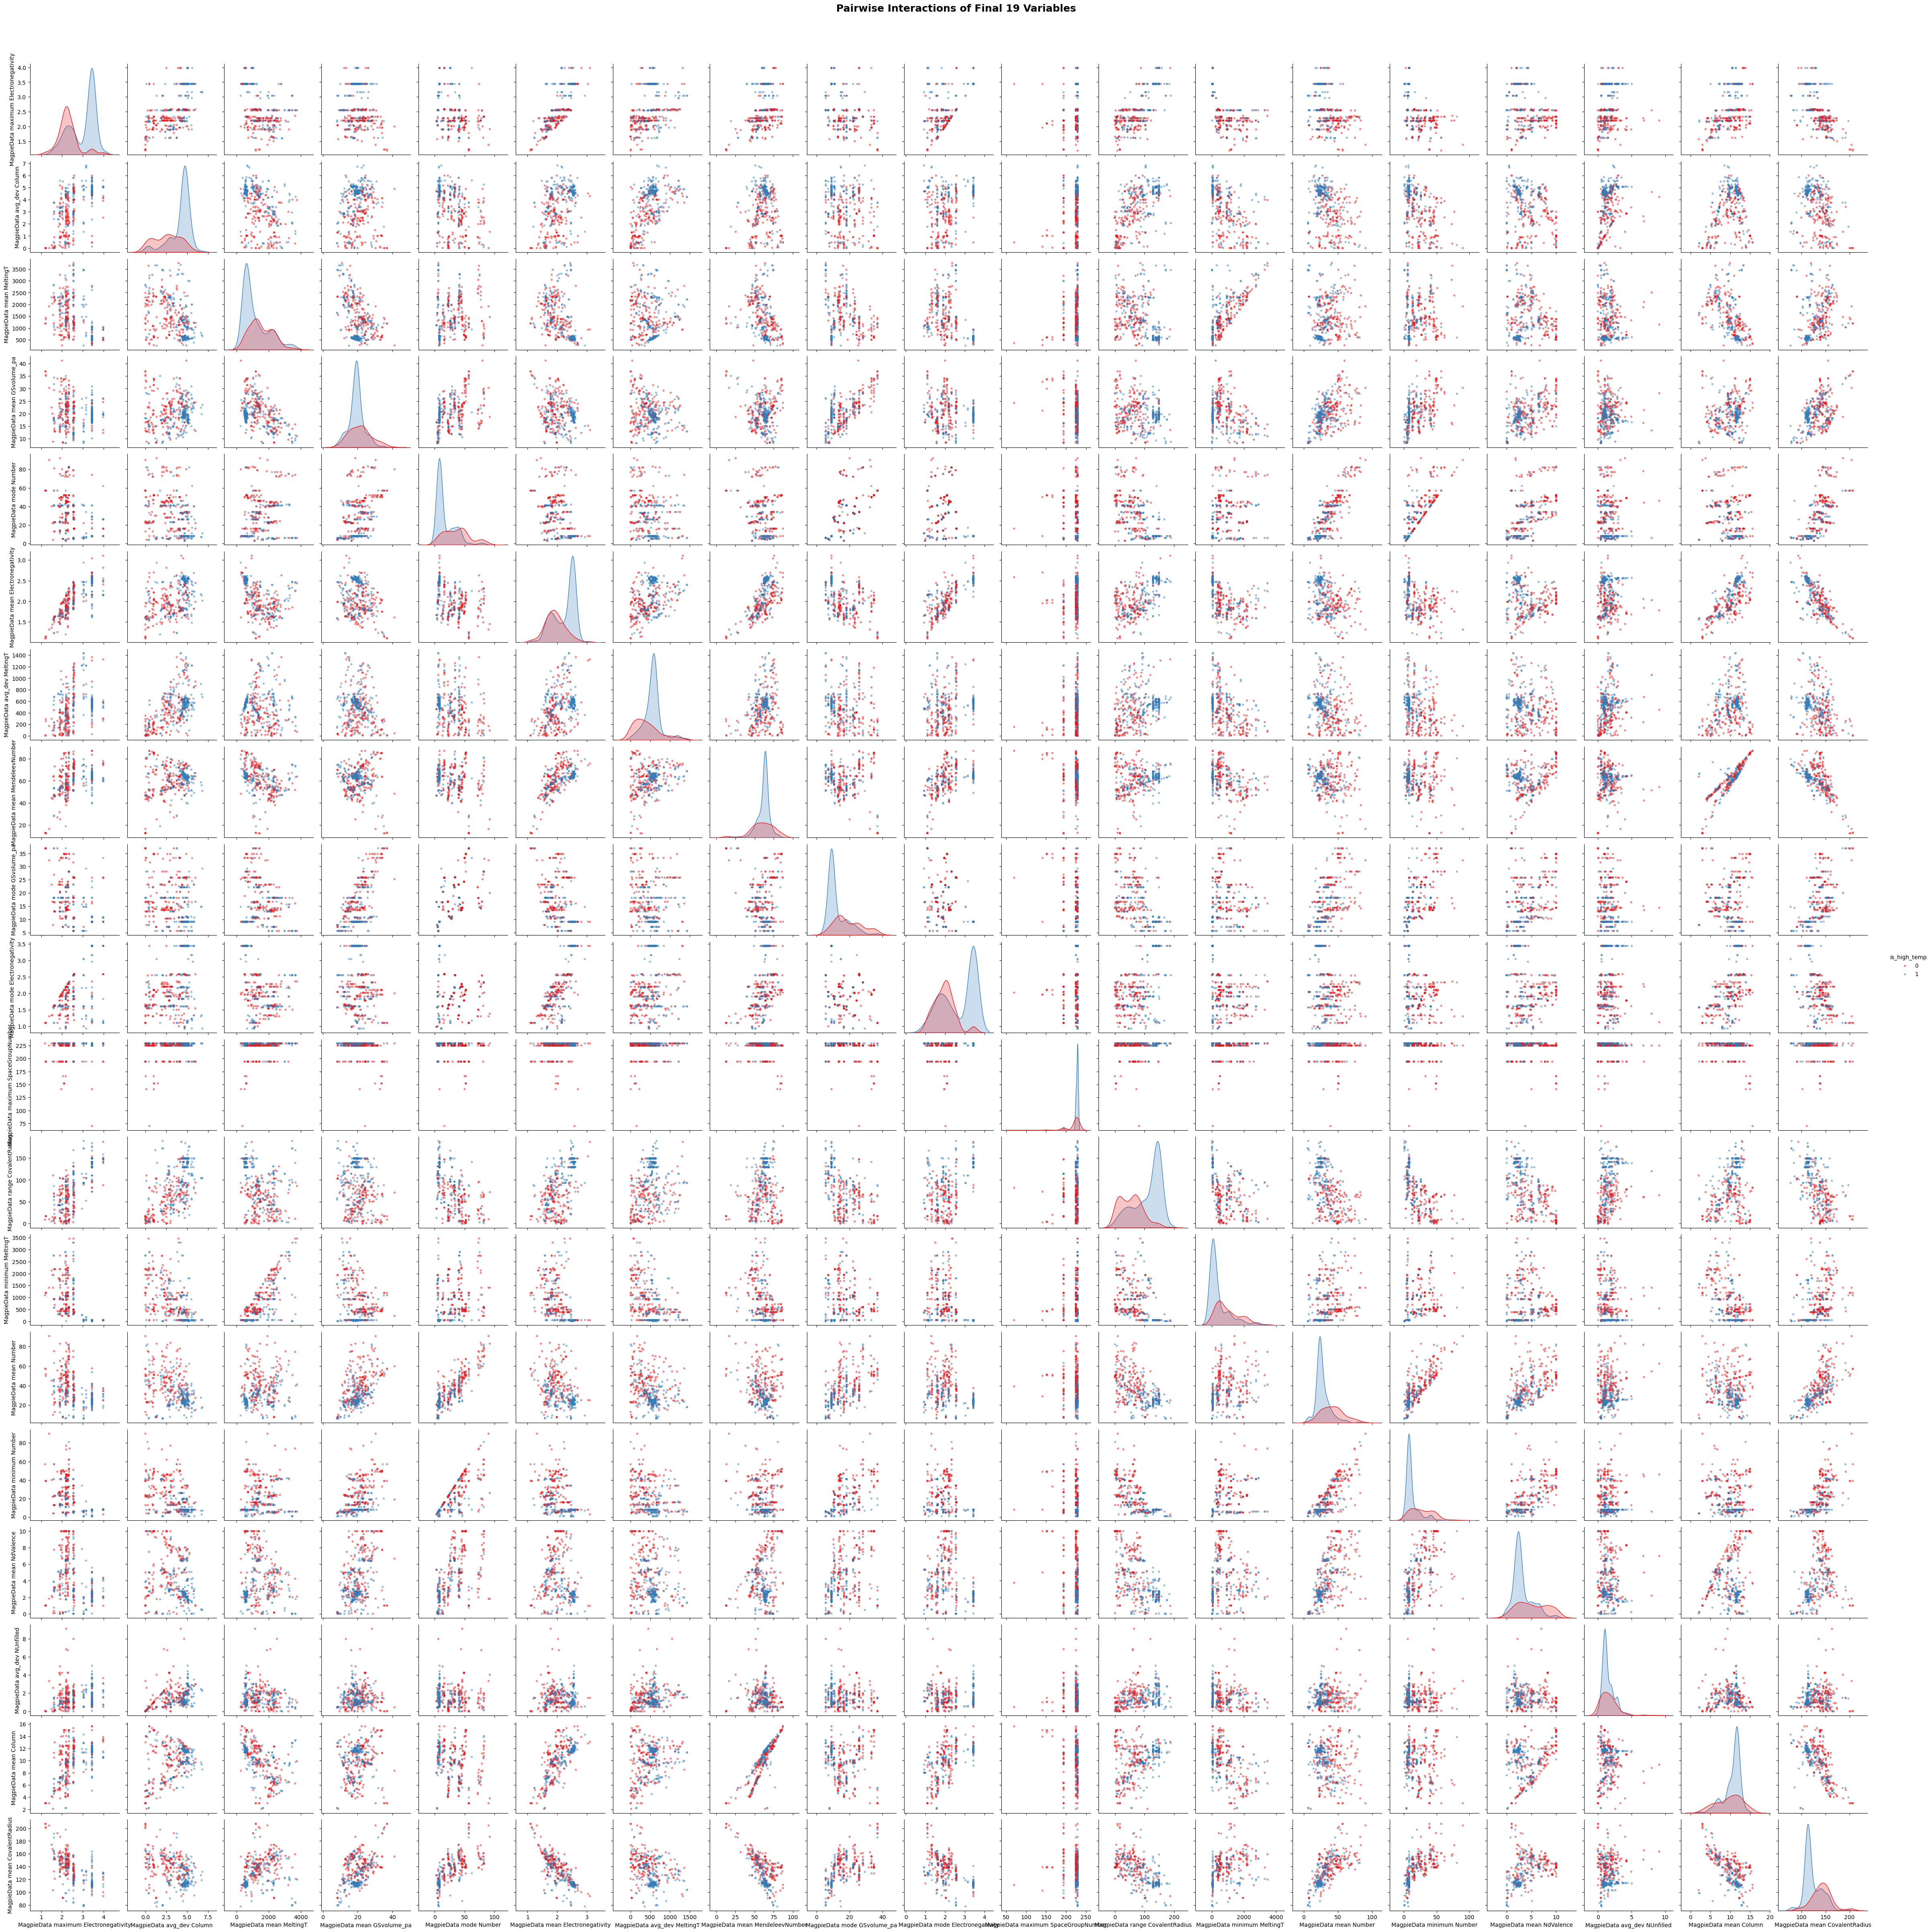

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

print("=== Generating Pairwise Scatter Plots ===\n")

# 1. Take a safe random sample of the training data
# (Plotting 289 graphs with hundreds of thousands of rows will crash your notebook!)
sample_size = 500 
print(f"Taking a random sample of {sample_size} rows for safe visualization...")

# Create a list that includes your features PLUS the target variable (so we can color-code the dots)
plot_columns = final_custom_features + ['is_high_temp']

# Create the subset dataframe
plot_df = train_df[plot_columns].sample(n=sample_size, random_state=42)

print(f"Generating a {len(final_custom_features)}x{len(final_custom_features)} grid of plots...")
print("(This might take a couple of minutes depending on your computer. Please wait ⏳)")

# 2. Generate the Pairplot
# hue='p_Truth_isElectron' -> Colors the dots (e.g., Red for Background, Blue for Electron)
# vars=final_custom_features -> Ensures it only plots your features on the X and Y axes
# alpha=0.5 -> Makes the dots slightly transparent so you can see where they clump together
pair_plot = sns.pairplot(
    plot_df, 
    hue='is_high_temp', 
    vars=final_custom_features, 
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15, 'edgecolor': 'none'},
    palette='Set1'
)

# 3. Add a title to the entire grid
pair_plot.fig.suptitle(f"Pairwise Interactions of Final {len(final_custom_features)} Variables", y=1.02, fontsize=18, fontweight='bold')

# Show the plot
plt.show()

In [46]:
print(final_custom_features)

['MagpieData maximum Electronegativity', 'MagpieData avg_dev Column', 'MagpieData mean MeltingT', 'MagpieData mean GSvolume_pa', 'MagpieData mode Number', 'MagpieData mean Electronegativity', 'MagpieData avg_dev MeltingT', 'MagpieData mean MendeleevNumber', 'MagpieData mode GSvolume_pa', 'MagpieData mode Electronegativity', 'MagpieData maximum SpaceGroupNumber', 'MagpieData range CovalentRadius', 'MagpieData minimum MeltingT', 'MagpieData mean Number', 'MagpieData minimum Number', 'MagpieData mean NdValence', 'MagpieData avg_dev NUnfilled', 'MagpieData mean Column', 'MagpieData mean CovalentRadius']


In [47]:
import xgboost as xgb
from sklearn.metrics import log_loss, roc_auc_score
import pandas as pd

# 1. Filter the datasets strictly to your 15 chosen features
# (Assuming your target column is still named 'p_Truth_isElectron')
target_col = 'is_high_temp'

X_train_final = train_df[final_custom_features]
y_train = train_df[target_col]

X_val_final = val_df[final_custom_features]
y_val = val_df[target_col]

print(f"Training on {X_train_final.shape[1]} features...")

# 2. Calculate the exact imbalance ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
imbalance_ratio = neg_count / pos_count

print(f"Calculated scale_pos_weight: {imbalance_ratio:.2f} (To handle the 21% imbalance)\n")

# 3. Initialize the Baseline XGBoost model
# We use default settings (learning_rate=0.3, max_depth=6) but explicitly set the weight and random state
xgb_baseline = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='logloss'
)

# 4. Train the model
print("Training Baseline XGBoost model... (This is usually very fast)")
xgb_baseline.fit(X_train_final, y_train)

# 5. Predict probabilities on the UNSEEN validation data
# predict_proba returns [Probability of Class 0, Probability of Class 1]
# We only want the probability that it IS an electron (Class 1)
y_val_probs = xgb_baseline.predict_proba(X_val_final)[:, 1]

# 6. Calculate the final evaluation metrics
baseline_logloss = log_loss(y_val, y_val_probs)
baseline_auc = roc_auc_score(y_val, y_val_probs)

# 7. Print the Baseline Results
print("=========================================")
print("🏆 BASELINE XGBOOST PERFORMANCE")
print("=========================================")
print(f"Validation LogLoss: {baseline_logloss:.4f} (Lower is better)")
print(f"Validation ROC-AUC: {baseline_auc:.4f} (Higher is better, Max is 1.0)")
print("=========================================")

Training on 19 features...
Calculated scale_pos_weight: 0.60 (To handle the 21% imbalance)

Training Baseline XGBoost model... (This is usually very fast)
🏆 BASELINE XGBOOST PERFORMANCE
Validation LogLoss: 0.2079 (Lower is better)
Validation ROC-AUC: 0.9714 (Higher is better, Max is 1.0)


In [48]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import log_loss, roc_auc_score
import pandas as pd

# 1. Define the Hyperparameter "Grid"
# This is the menu of options the algorithm will test
param_grid = {
    'n_estimators': [800, 850, 900, 950 ],        # How many trees to build
    'max_depth': [ 9,10, 11, 12],            # Maximum depth of each tree
    'learning_rate': [ 0.01, 0.02, 0.025, 0.03],     # How much each tree contributes
    'subsample': [0.5, 0.6, 0.7, 0.8],                # Fraction of rows used per tree (prevents overfitting)
    'colsample_bytree': [0.3, 0.35, 0.4, 0.45],         # Fraction of columns used per tree
    'gamma': [0, 0.05, 0.1, 0.15, 0.175]                 # Minimum loss reduction required to make a further partition
}

# 2. Re-calculate the exact imbalance ratio
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
imbalance_ratio = neg_count / pos_count

print("Setting up Hyperparameter Tuning via RandomizedSearchCV...")
print("⏳ Note: This will test multiple combinations and cross-validate them. It will take a few minutes!\n")

# 3. Initialize the bare-bones base model
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='logloss'
)

# 4. Set up the Randomized Search
# - n_iter=20: We tell it to test 20 different random combinations from our grid
# - cv=3: 3-fold cross validation (it tests every combination 3 times on different data slices)
# - scoring='neg_log_loss': We explicitly tell it that its goal is to minimize LogLoss!
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_log_loss',
    cv=3,
    verbose=1,  # This prints out the progress as it works
    random_state=42,
    n_jobs=-1
)

# 5. Execute the search (The heavy lifting happens here)
random_search.fit(X_train_final, y_train)

# 6. Extract the absolute best model and its parameters
best_params = random_search.best_params_
best_xgb_model = random_search.best_estimator_

print("\n✅ Tuning Complete!")
print("=========================================")
print("🏆 BEST HYPERPARAMETERS FOUND:")
for param, value in best_params.items():
    print(f" - {param}: {value}")
print("=========================================")

# 7. Evaluate the perfectly tuned model on the UNSEEN validation data
y_val_probs_tuned = best_xgb_model.predict_proba(X_val_final)[:, 1]

tuned_logloss = log_loss(y_val, y_val_probs_tuned)
tuned_auc = roc_auc_score(y_val, y_val_probs_tuned)

print("\n=========================================")
print("🚀 TUNED XGBOOST PERFORMANCE ON VALIDATION DATA")
print("=========================================")
print(f"Baseline Validation LogLoss: {baseline_logloss:.4f}")
print(f"Tuned Validation LogLoss:    {tuned_logloss:.4f}  <-- Look for the drop!")
print("---")
print(f"Baseline Validation ROC-AUC: {baseline_auc:.4f}")
print(f"Tuned Validation ROC-AUC:    {tuned_auc:.4f}  <-- Look for the increase!")
print("=========================================")

Setting up Hyperparameter Tuning via RandomizedSearchCV...
⏳ Note: This will test multiple combinations and cross-validate them. It will take a few minutes!

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Tuning Complete!
🏆 BEST HYPERPARAMETERS FOUND:
 - subsample: 0.7
 - n_estimators: 900
 - max_depth: 9
 - learning_rate: 0.02
 - gamma: 0.1
 - colsample_bytree: 0.45

🚀 TUNED XGBOOST PERFORMANCE ON VALIDATION DATA
Baseline Validation LogLoss: 0.2079
Tuned Validation LogLoss:    0.2035  <-- Look for the drop!
---
Baseline Validation ROC-AUC: 0.9714
Tuned Validation ROC-AUC:    0.9726  <-- Look for the increase!


In [49]:
from sklearn.model_selection import train_test_split

# --- Recreate the 3-Way Split to define vault_df ---
target_col = 'is_high_temp'

# 1. Lock away the 10% VAULT SET
temp_train_df, vault_df = train_test_split(
    df, 
    test_size=0.10,             
    random_state=42,            
    stratify=df[target_col]     
)

# 2. Split the remaining 90% into TRAIN and VALIDATION
train_df, val_df = train_test_split(
    temp_train_df, 
    test_size=(0.10 / 0.90),    
    random_state=42,            
    stratify=temp_train_df[target_col]     
)

print(f"✅ Memory restored! vault_df is now loaded with {vault_df.shape[0]} unseen rows.")

✅ Memory restored! vault_df is now loaded with 1367 unseen rows.


=== 🔓 Unlocking the Vault: Final Test Set Evaluation ===

🏆 FINAL UNSEEN VAULT PERFORMANCE
Vault LogLoss:  0.2007
Vault ROC-AUC:  0.9727
Vault Accuracy: 92.32%

--- Detailed Classification Report ---
                precision    recall  f1-score   support

Background (0)       0.89      0.91      0.90       510
  Electron (1)       0.94      0.93      0.94       857

      accuracy                           0.92      1367
     macro avg       0.92      0.92      0.92      1367
  weighted avg       0.92      0.92      0.92      1367



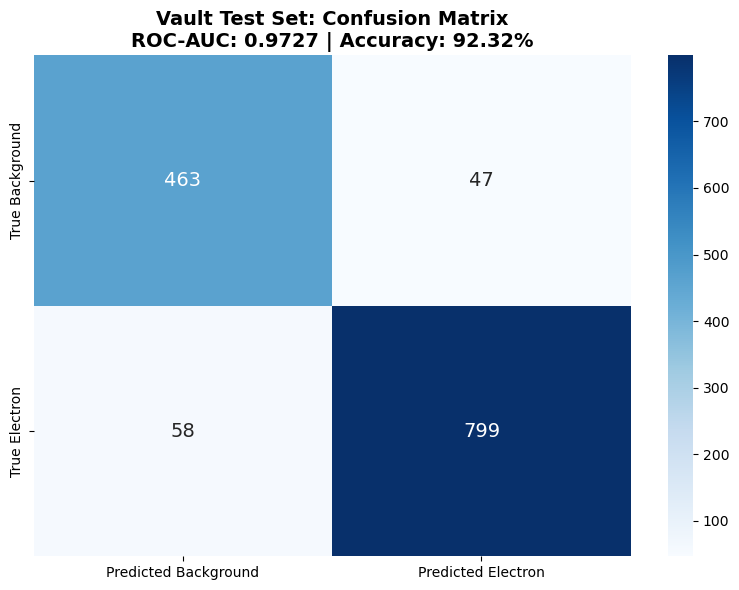

In [50]:
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 🔓 Unlocking the Vault: Final Test Set Evaluation ===\n")

# 1. Guarantee exact feature match
# We pull the exact columns used during training so the model doesn't get confused
final_features = X_train_final.columns.tolist()

# 2. Prepare the Vault Data
# (Using vault_df from the 3-way split we did earlier)
X_test_vault = vault_df[final_features]
y_test_vault = vault_df['is_high_temp']

# 3. Make Predictions on the Unseen Data using the BEST tuned model
test_predictions_proba = best_xgb_model.predict_proba(X_test_vault)[:, 1]
test_predictions_class = best_xgb_model.predict(X_test_vault)

# 4. Calculate the Official Scores
test_logloss = log_loss(y_test_vault, test_predictions_proba)
test_roc_auc = roc_auc_score(y_test_vault, test_predictions_proba)
test_accuracy = accuracy_score(y_test_vault, test_predictions_class)

print("=========================================")
print("🏆 FINAL UNSEEN VAULT PERFORMANCE")
print("=========================================")
print(f"Vault LogLoss:  {test_logloss:.4f}")
print(f"Vault ROC-AUC:  {test_roc_auc:.4f}")
print(f"Vault Accuracy: {test_accuracy * 100:.2f}%\n")

print("--- Detailed Classification Report ---")
# Precision: When it guesses Electron, how often is it actually an Electron?
# Recall: Out of all true Electrons, how many did it manage to find?
print(classification_report(y_test_vault, test_predictions_class, target_names=['Background (0)', 'Electron (1)']))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_vault, test_predictions_class)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Background', 'Predicted Electron'], 
            yticklabels=['True Background', 'True Electron'],
            annot_kws={"size": 14})

plt.title(f"Vault Test Set: Confusion Matrix\nROC-AUC: {test_roc_auc:.4f} | Accuracy: {test_accuracy * 100:.2f}%", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()